In [1]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
# Uploading the dataset
data = pd.read_csv('co2.csv')

In [3]:
# Viewing the dataset
data.head()

,engine,cylandr,fuelcomb,out1
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


<Axes: >

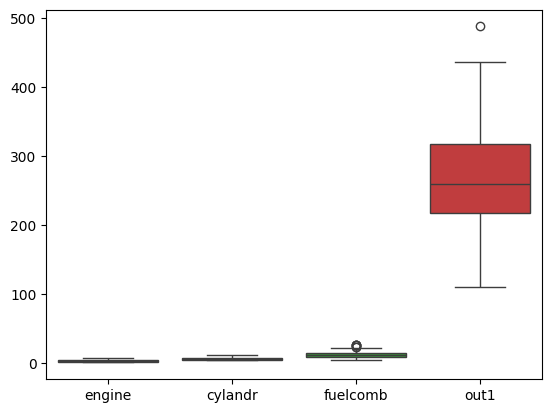

In [4]:
# Checking the dataset for noises
sns.boxplot(data)

In [5]:
# Cleaning function to erase noise
def cleaning(series : pd.Series , factor : float = 1.5):
    q1 , q3 = series.quantile([0.25 , 0.75])
    iqr = q3 - q1
    low = q1 - iqr * factor
    high = q3 + iqr * factor
    return low , high

In [6]:
# Enforcing the function on noisy columns
for i in ['fuelcomb' , 'out1']:
    if i in data.columns:
        a = data[i].astype(float)
        low , high = cleaning(a , factor = 1.5)
        result = (a < low ) | (a > high)
        print(result.sum())
        data.loc[a < low , i] = low
        data.loc[a > high , i] = high

6
1


<Axes: >

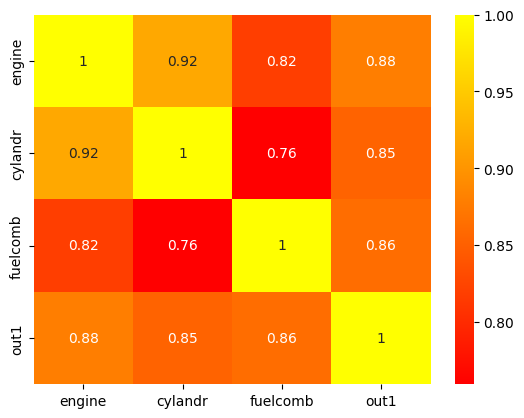

In [7]:
# Understanding the relationship between columns
sns.heatmap(data.corr() , annot = True , cmap = 'autumn')

In [8]:
# Creating X and y
X = data.drop('out1' , axis = 1)
y = data['out1']

In [9]:
# Splitting the data in training and testing sets
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2)

In [10]:
# Training a model
lin = LinearRegression()
lin.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# Predicting
lin_pred = lin.predict(X_test)

In [12]:
# Model accuracy
r2_score(y_test , lin_pred)

0.842297836667375